fatal: destination path 'aprendizaje_profundo' already exists and is not an empty directory.


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 931 (3.64 KB)

 Trainable params: 931 (3.64 KB)

 Non-trainable params: 0 (0.00 B)

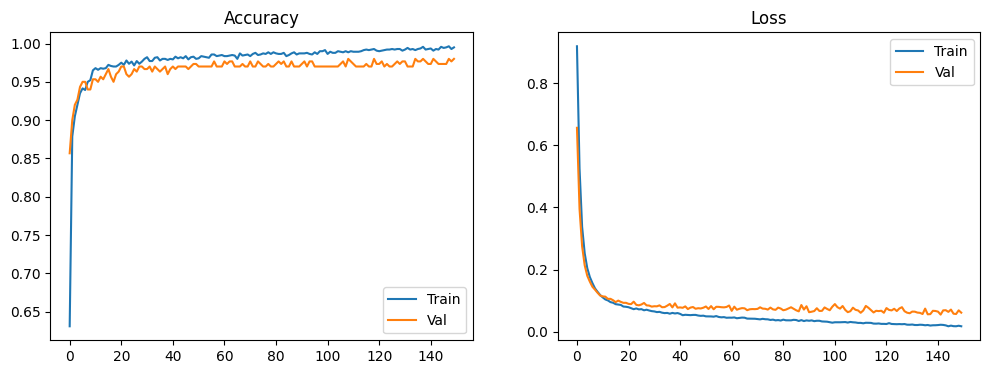

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Total Params:     931
Train Accuracy:   0.9943
Val Accuracy:     0.9800
Test Accuracy:    0.9767
F1 Macro (Test):  0.9459


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

!git clone https://github.com/macaspe4/aprendizaje_profundo.git

sys.path.append('/content/aprendizaje_profundo')

from modelos.modelo_complejos1 import crear_modelo

df = pd.read_csv('wfh_burnout_dataset.csv')
features = ['work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken',
            'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion',
            'isolation_index', 'fatigue_score']
X = df[features]
y = LabelEncoder().fit_transform(df['burnout_risk'])

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

model = crear_modelo(X_train_sc.shape[1])
model.summary()

history = model.fit(X_train_sc, y_train, validation_data=(X_val_sc, y_val),
                    epochs=150, verbose=0)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val'); plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val'); plt.title('Loss'); plt.legend()
plt.show()

y_train_pred = np.argmax(model.predict(X_train_sc), axis=1)
y_val_pred = np.argmax(model.predict(X_val_sc), axis=1)
y_test_pred = np.argmax(model.predict(X_test_sc), axis=1)

print(f"Total Params:     {model.count_params()}")
print(f"Train Accuracy:   {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Val Accuracy:     {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Test Accuracy:    {accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1 Macro (Test):  {f1_score(y_test, y_test_pred, average='macro'):.4f}")


### Conclusión
Este primer modelo usa dos capas ocultas de 32 y 16 neuronas, con un total de 931 parámetros. Los resultados son muy buenos: 99,43% de precisión en entrenamiento, 98,00% en validación y 97,67% en test.

Como los valores son bastante parecidos entre sí, significa que el modelo generaliza bien y funciona correctamente con datos nuevos. Además, el F1 Macro de 0,9459 indica que clasifica bastante bien las tres categorías de riesgo de burnout (bajo, medio y alto).

Aun así, el hecho de que la precisión en entrenamiento esté muy cerca del 100% sugiere un pequeño sobreajuste, es decir, que el modelo puede estar aprendiendo demasiado los datos de entrenamiento. Por eso, en el Modelo 2 se añade Dropout, para reducir esa memorización y hacer el modelo más robusto.